Upload your b19-b30 Excel files now.


Saving b19.xlsx to b19.xlsx
Saving b20.xlsx to b20.xlsx
Saving b21.xlsx to b21.xlsx
Saving b22.xls to b22.xls
Saving b22.xlsx to b22.xlsx
Saving b23.xls to b23.xls
Saving b23.xlsx to b23.xlsx
Saving b24.xls to b24.xls
Saving b24.xlsx to b24.xlsx
Saving b25.xls to b25.xls
Saving b25.xlsx to b25.xlsx
Saving b26.xls to b26.xls
Saving b26.xlsx to b26.xlsx
Saving b27.xls to b27.xls
Saving b27.xlsx to b27.xlsx
Saving b28.xls to b28.xls
Saving b28.xlsx to b28.xlsx
Saving b29.xls to b29.xls
Saving b29.xlsx to b29.xlsx
Saving b30.xls to b30.xls
Saving b30.xlsx to b30.xlsx

Uploaded files:
- b19.xlsx
- b20.xlsx
- b21.xlsx
- b22.xls
- b22.xlsx
- b23.xls
- b23.xlsx
- b24.xls
- b24.xlsx
- b25.xls
- b25.xlsx
- b26.xls
- b26.xlsx
- b27.xls
- b27.xlsx
- b28.xls
- b28.xlsx
- b29.xls
- b29.xlsx
- b30.xls
- b30.xlsx

Files used:
- b19.xlsx
- b20.xlsx
- b21.xlsx
- b22.xlsx
- b23.xlsx
- b24.xlsx
- b25.xlsx
- b26.xlsx
- b27.xlsx
- b28.xlsx
- b29.xlsx
- b30.xlsx

Loaded b19.xlsx
Table type: energy_sources
Co

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


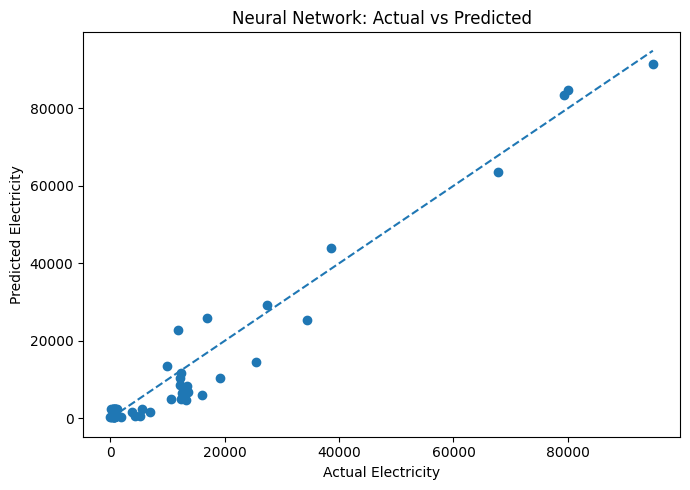

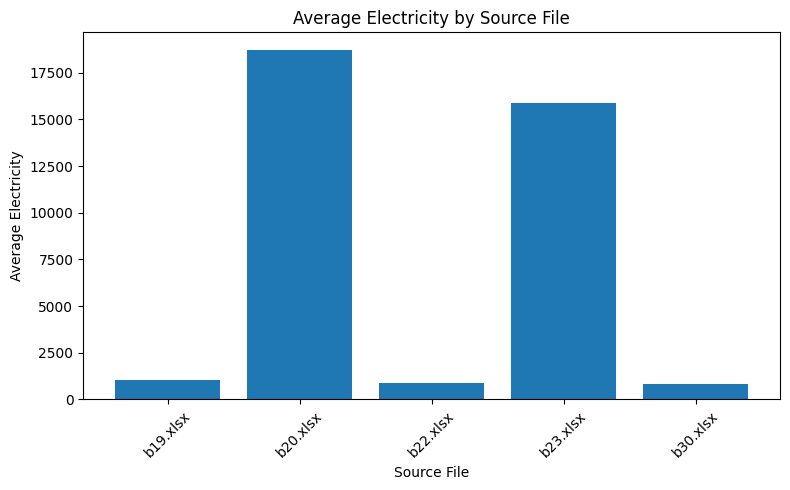

In [1]:
# ==========================================
# Google Colab Neural Network for EIA files
# Improved version with Year_Index + Total_Energy
# ==========================================

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Upload files
# -----------------------------
print("Upload your b19-b30 Excel files now.")
uploaded = files.upload()

print("\nUploaded files:")
for name in uploaded.keys():
    print("-", name)

# -----------------------------
# Helper functions
# -----------------------------
def clean_text(x):
    if pd.isna(x):
        return ""
    s = str(x).replace("\n", " ").replace("\r", " ").strip()
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_header_text(x):
    s = clean_text(x).lower()

    replacements = {
        "elec- tricity": "electricity",
        "elec tricity": "electricity",
        "gener- ation": "generation",
        "manu- facturing": "manufacturing",
        "space-heating": "space heating",
        "water-heating": "water heating",
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    s = s.replace("-", " ")
    s = s.replace("/", " ")
    s = s.replace(",", "")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_rse_header(h):
    h = normalize_header_text(h)
    return h == "rse" or "rse" in h or "relative standard error" in h

def detect_table_type(raw_df):
    search_rows = min(8, len(raw_df))
    text_blob = " ".join(
        clean_text(raw_df.iloc[i, 0]) for i in range(search_rows)
        if raw_df.shape[1] > 0
    )
    t = normalize_header_text(text_blob)

    if "energy sources" in t and "space heating" not in t and "primary" not in t:
        return "energy_sources"
    elif "energy end uses" in t:
        return "end_uses"
    elif "space heating energy sources" in t and "primary" not in t:
        return "space_heating_sources"
    elif "primary space heating energy sources" in t:
        return "primary_heating_source"
    else:
        return "unknown"

def standardize_columns(raw_headers):
    standardized = []
    keep_mask = []

    for idx, h in enumerate(raw_headers):
        h_norm = normalize_header_text(h)

        if is_rse_header(h):
            standardized.append(f"DROP_RSE_{idx}")
            keep_mask.append(False)
            continue

        if idx == 0:
            standardized.append("Category")
            keep_mask.append(True)
        elif h_norm == "all buildings":
            standardized.append("All_Buildings")
            keep_mask.append(True)
        elif h_norm == "":
            standardized.append(f"Blank_{idx}")
            keep_mask.append(False)
        elif "electricity generation" in h_norm:
            standardized.append("Electricity_Generation")
            keep_mask.append(True)
        elif h_norm == "electricity":
            standardized.append("Electricity")
            keep_mask.append(True)
        elif "natural gas" in h_norm:
            standardized.append("Natural_Gas")
            keep_mask.append(True)
        elif "fuel oil" in h_norm:
            standardized.append("Fuel_Oil")
            keep_mask.append(True)
        elif "district chilled water" in h_norm or "district chilled" in h_norm:
            standardized.append("District_Chilled_Water")
            keep_mask.append(True)
        elif "district heat" in h_norm:
            standardized.append("District_Heat")
            keep_mask.append(True)
        elif "propane" in h_norm:
            standardized.append("Propane")
            keep_mask.append(True)
        elif "solar" in h_norm:
            standardized.append("Solar")
            keep_mask.append(True)
        elif "wood" in h_norm or "coal" in h_norm:
            standardized.append("Wood_Coal_Other")
            keep_mask.append(True)
        elif h_norm in ["other1", "other 1", "other"]:
            standardized.append("Other")
            keep_mask.append(True)
        elif "space heating" in h_norm:
            standardized.append("Space_Heating")
            keep_mask.append(True)
        elif h_norm == "cooling":
            standardized.append("Cooling")
            keep_mask.append(True)
        elif "water heating" in h_norm:
            standardized.append("Water_Heating")
            keep_mask.append(True)
        elif "cooking" in h_norm:
            standardized.append("Cooking")
            keep_mask.append(True)
        elif "manufacturing" in h_norm:
            standardized.append("Manufacturing")
            keep_mask.append(True)
        elif "lighting" in h_norm:
            standardized.append("Lighting")
            keep_mask.append(True)
        else:
            standardized.append(re.sub(r"\W+", "_", h_norm).strip("_").title())
            keep_mask.append(True)

    seen = {}
    unique_cols = []
    for col in standardized:
        if col not in seen:
            seen[col] = 0
            unique_cols.append(col)
        else:
            seen[col] += 1
            unique_cols.append(f"{col}_{seen[col]}")

    return unique_cols, keep_mask

def remove_nondata_rows(df):
    if "Category" not in df.columns:
        return df

    bad_patterns = [
        "rse row factors",
        "rse column factors",
        "row factors",
        "column factors",
        "see notes",
        "more than one may apply",
        "no data",
        "weather sensitive",
        "rows may not sum",
        "percents may not add",
    ]

    category_clean = df["Category"].astype(str).str.lower().str.strip()
    mask = pd.Series(True, index=df.index)

    for pat in bad_patterns:
        mask &= ~category_clean.str.contains(pat, na=False)

    mask &= category_clean.ne("")
    return df[mask].reset_index(drop=True)

def get_preferred_files():
    all_files = glob.glob("b*.xls") + glob.glob("b*.xlsx")
    preferred = {}

    for f in sorted(all_files):
        base = os.path.splitext(os.path.basename(f))[0]
        ext = os.path.splitext(f)[1].lower()

        if base not in preferred:
            preferred[base] = f
        elif ext == ".xlsx":
            preferred[base] = f

    return sorted(preferred.values())

def load_eia_table(filename):
    raw = pd.read_excel(filename, header=None)

    table_type = detect_table_type(raw)

    header_marker_row = None
    for i, row in raw.iterrows():
        row_text = row.astype(str).fillna("").apply(normalize_header_text)
        if (row_text == "all buildings").any():
            header_marker_row = i
            break

    if header_marker_row is None:
        raise ValueError(f"Could not detect header row in {filename}")

    raw_headers = raw.iloc[header_marker_row].tolist()
    columns, keep_mask = standardize_columns(raw_headers)

    data = raw.iloc[header_marker_row + 1:].reset_index(drop=True)
    data.columns = columns

    cols_to_keep = [col for col, keep in zip(data.columns, keep_mask) if keep]
    data = data[cols_to_keep]

    data = remove_nondata_rows(data)

    for col in data.columns:
        if col != "Category":
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data["Source_File"] = os.path.basename(filename)
    data["Table_Type"] = table_type

    # extract numeric file index, e.g. b19 -> 19
    match = re.search(r"b(\d+)", os.path.basename(filename).lower())
    data["Year_Index"] = int(match.group(1)) if match else np.nan

    numeric_candidate_cols = [
        c for c in data.columns if c not in ["Category", "Source_File", "Table_Type"]
    ]
    data = data.dropna(subset=numeric_candidate_cols, how="all").reset_index(drop=True)

    return data

# -----------------------------
# Load files
# -----------------------------
files_list = get_preferred_files()
print("\nFiles used:")
for f in files_list:
    print("-", f)

tables = []
for file in files_list:
    try:
        temp = load_eia_table(file)
        tables.append(temp)
        print(f"\nLoaded {file}")
        print("Table type:", temp["Table_Type"].iloc[0] if not temp.empty else "empty")
        print("Columns:", temp.columns.tolist())
        print("Rows:", len(temp))
    except Exception as e:
        print(f"\nCould not load {file}: {e}")

if not tables:
    raise ValueError("No usable tables were loaded.")

combined_data = pd.concat(tables, ignore_index=True, sort=False)

print("\n=== Table Type Counts ===")
print(combined_data["Table_Type"].value_counts(dropna=False))

print("\n=== Combined Columns ===")
print(combined_data.columns.tolist())

# -----------------------------
# Use only energy source tables
# -----------------------------
model_subset = combined_data[
    combined_data["Table_Type"] == "energy_sources"
].copy()

print("\n=== Energy Source Subset Files ===")
print(model_subset["Source_File"].value_counts())

# -----------------------------
# Create Total_Energy
# -----------------------------
energy_parts = [
    "Natural_Gas",
    "Fuel_Oil",
    "District_Heat",
    "District_Chilled_Water",
    "Propane"
]

present_energy_parts = [c for c in energy_parts if c in model_subset.columns]

if len(present_energy_parts) == 0:
    raise ValueError("No common energy source columns found for Total_Energy.")

model_subset["Total_Energy"] = model_subset[present_energy_parts].fillna(0).sum(axis=1)

print("\nEnergy columns used for Total_Energy:", present_energy_parts)

# -----------------------------
# Feature selection
# -----------------------------
candidate_features = [
    "Total_Energy",
    "Natural_Gas",
    "Fuel_Oil",
    "District_Heat",
    "District_Chilled_Water",
    "Propane",
    "Year_Index"
]

available_features = [c for c in candidate_features if c in model_subset.columns]

print("\nCandidate features:", candidate_features)
print("Available features:", available_features)

if "Electricity" not in model_subset.columns:
    raise ValueError("No Electricity column found. Cannot train model.")

# inspect non-null counts
print("\n=== Non-null counts ===")
print(model_subset[available_features + ["Electricity"]].notna().sum())

# build model data
model_data = model_subset[available_features + ["Electricity"]].dropna()

print("\n=== Model Data Preview ===")
print(model_data.head())
print("\nModel dataset shape:", model_data.shape)

if len(model_data) < 10:
    raise ValueError("Not enough cleaned rows for training.")

# -----------------------------
# Train Neural Network
# -----------------------------
X = model_data[available_features]
y = model_data["Electricity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== Neural Network Results ===")
print("Features used:", available_features)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)

# -----------------------------
# Plot 1: Actual vs Predicted
# -----------------------------
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Electricity")
plt.ylabel("Predicted Electricity")
plt.title("Neural Network: Actual vs Predicted")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Average Electricity by File
# -----------------------------
file_summary = model_subset.groupby("Source_File")["Electricity"].mean().dropna()

if not file_summary.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(file_summary.index.astype(str), file_summary.values)
    plt.xticks(rotation=45)
    plt.xlabel("Source File")
    plt.ylabel("Average Electricity")
    plt.title("Average Electricity by Source File")
    plt.tight_layout()
    plt.show()